# Playground: exploring NASA C-MAPSS FD001

Run cells top to bottom with **Shift+Enter**. Change the numbers, re-run and see what happens.

**Remember:** each row is *one engine on one flight (cycle)*. In the training data, every engine's last row is the flight it failed on.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
from data import load_train, load_test, SENSOR_COLS, SETTING_COLS

pd.set_option("display.max_columns", 30)
train = load_train("FD001")
test, test_rul = load_test("FD001")

## 1. What does the raw table look like?

In [2]:
train.head(10)

,unit,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,21.61,554.67,2388.02,9049.68,1.3,47.16,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,21.61,554.34,2388.02,9059.13,1.3,47.36,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,21.61,553.85,2388.00,9040.80,1.3,47.24,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,21.61,553.69,2388.05,9046.46,1.3,47.29,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,21.61,553.59,2388.05,9051.70,1.3,47.03,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


In [3]:
train.shape  # (rows, columns)

(20631, 26)

## 2. Look at one engine's whole life
Try changing `UNIT` to any number from 1 to 100.

In [4]:
UNIT = 1
engine = train[train["unit"] == UNIT]
print(f"Engine {UNIT} failed on flight {engine['cycle'].max()}")
engine.tail()

Engine 1 failed on flight 192


,unit,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,21.61,551.94,2388.31,9037.91,1.3,48.00,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,21.61,550.70,2388.27,9044.55,1.3,48.08,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,21.61,551.29,2388.29,9040.58,1.3,48.33,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,21.61,550.92,2388.28,9042.76,1.3,48.15,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,21.61,551.25,2388.32,9033.22,1.3,48.25,520.08,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649


## 3. How long do engines live?
This is why a fixed schedule is costly: lifetimes vary a lot.

count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0
Name: cycle, dtype: float64


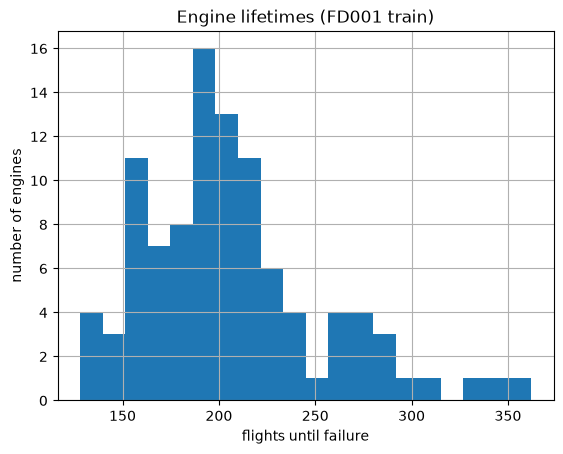

In [5]:
life = train.groupby("unit")["cycle"].max()
print(life.describe().round(1))

life.hist(bins=20)
plt.xlabel("flights until failure"); plt.ylabel("number of engines")
plt.title("Engine lifetimes (FD001 train)")
plt.show()

### Try it: what would a fixed schedule do?
If we serviced every engine at `SERVICE_AT` flights, how many would already have failed, and how much life would we waste on the others?

In [6]:
SERVICE_AT = 150

failed_first = (life < SERVICE_AT).sum()
wasted = (life[life >= SERVICE_AT] - SERVICE_AT).mean()
print(f"Service every {SERVICE_AT} flights:")
print(f"  {failed_first} of 100 engines fail before service")
print(f"  engines that survive still had {wasted:.0f} flights left on average (wasted)")

Service every 150 flights:
  6 of 100 engines fail before service
  engines that survive still had 61 flights left on average (wasted)


## 4. Which sensors never change?
A sensor with a standard deviation of ~0 is a flat line, so it tells us nothing.

In [7]:
train[SENSOR_COLS].std().sort_values().round(4)

s1      0.0000
s19     0.0000
s18     0.0000
s10     0.0000
s16     0.0000
s5      0.0000
s6      0.0014
s15     0.0375
s8      0.0710
s13     0.0719
s21     0.1083
s20     0.1807
s11     0.2671
s2      0.5001
s12     0.7376
s7      0.8851
s17     1.5488
s3      6.1311
s4      9.0006
s14    19.0762
s9     22.0829
dtype: float64

## 5. Plot any sensor across several engines
The x axis is aligned so that **0 = the failure point**. Try `s2`, `s4`, `s7`, `s11`, `s9` or `s14`.

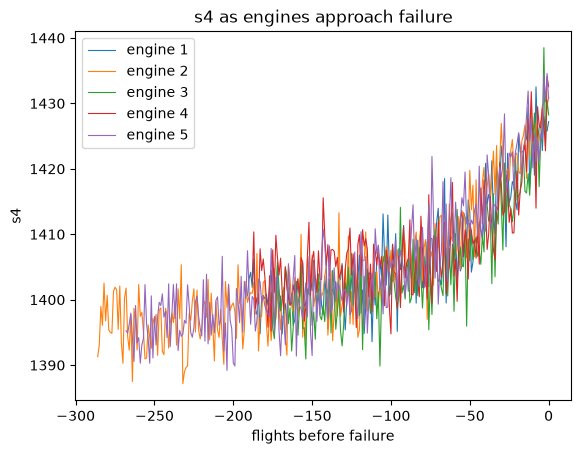

In [8]:
SENSOR = "s4"
UNITS = [1, 2, 3, 4, 5]

for u in UNITS:
    eng = train[train["unit"] == u]
    plt.plot(eng["cycle"] - eng["cycle"].max(), eng[SENSOR], lw=0.8, label=f"engine {u}")
plt.xlabel("flights before failure"); plt.ylabel(SENSOR)
plt.title(f"{SENSOR} as engines approach failure")
plt.legend(); plt.show()

## 6. Preview of Step 2: flights left (RUL)
For each row: **flights left = flight it failed on − current flight**.

In [13]:
df = train.copy()
df["rul"] = df.groupby("unit")["cycle"].transform("max") - df["cycle"]
df[["unit", "cycle", "rul", "s4", "s11"]].head(10)

,unit,cycle,rul,s4,s11
0,1,1,191,1400.60,47.47
1,1,2,190,1403.14,47.49
2,1,3,189,1404.20,47.27
3,1,4,188,1401.87,47.13
4,1,5,187,1406.22,47.28
5,1,6,186,1398.37,47.16
6,1,7,185,1397.77,47.36
7,1,8,184,1400.97,47.24
8,1,9,183,1394.80,47.29
9,1,10,182,1400.46,47.03


### Which sensors move with RUL?
Correlation near **+1 or −1** means the sensor tracks wear strongly. Near **0** means it's useless.

In [10]:
df[SENSOR_COLS + ["rul"]].corr()["rul"].drop("rul").sort_values().round(3)

s11   -0.696
s4    -0.679
s15   -0.643
s2    -0.606
s17   -0.606
s3    -0.585
s8    -0.564
s13   -0.563
s9    -0.390
s14   -0.307
s6    -0.128
s20    0.629
s21    0.636
s7     0.657
s12    0.672
s1       NaN
s5       NaN
s10      NaN
s16      NaN
s18      NaN
s19      NaN
Name: rul, dtype: float64

### Why cap RUL at 125?
Scatter one sensor against RUL. Far from failure (right side) it's a flat noisy cloud, so the model can't tell 300 flights left from 150. Close to failure (left side) it moves clearly.

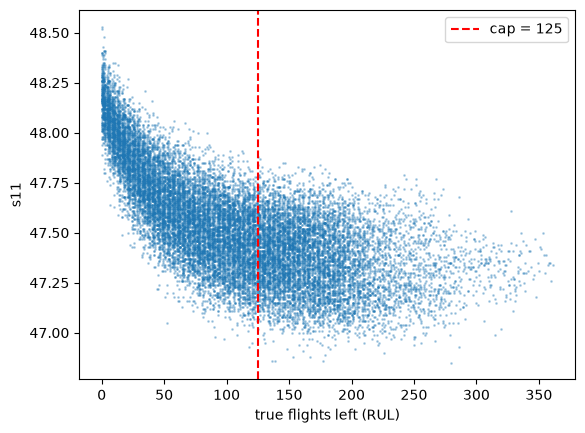

In [11]:
SENSOR = "s11"
plt.scatter(df["rul"], df[SENSOR], s=1, alpha=0.3)
plt.axvline(125, color="red", ls="--", label="cap = 125")
plt.xlabel("true flights left (RUL)"); plt.ylabel(SENSOR)
plt.legend(); plt.show()

## 7. The test set: engines cut off mid-life
We see each engine up to some flight, and NASA tells us the true flights left after that. This is what the model will be graded on.

In [12]:
last_seen = test.groupby("unit")["cycle"].max()
pd.DataFrame({"flights_seen": last_seen, "true_flights_left": test_rul}).head(10)

,flights_seen,true_flights_left
1,31,112
2,49,98
3,126,69
4,106,82
5,98,91
6,105,93
7,160,91
8,166,95
9,55,111
10,192,96


## Your playground
Try anything here.